<a href="https://colab.research.google.com/github/Muhammad-Umer1132/AI-ML-Internship-Tasks/blob/main/Task_3_Developershub_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 3: Heart Disease Prediction**

In [3]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Problem Statement:**
Heart disease is one of the leading causes of death worldwide. Early prediction of heart disease risk based on patient health data can save lives by enabling timely medical intervention. In this task, we build a **binary classification model** that predicts whether a patient is at risk of heart disease based on clinical measurements.


**Dataset**
- **Name:** Heart Disease UCI Dataset
- **Source:** Kaggle / UCI Machine Learning Repository
- **Target:** `target` — 1 = Heart Disease Present, 0 = No Heart Disease
- **Features:** 13 clinical features including age, cholesterol, blood pressure, etc.


**Objectives:**
1. Load and clean the dataset (handle missing values)
2. Perform Exploratory Data Analysis (EDA)
3. Train **Logistic Regression** and **Decision Tree** classifiers
4. Evaluate using **Accuracy**, **Confusion Matrix**, and **ROC-AUC Curve**
5. Identify the most important features affecting heart disease prediction

**Step 1: Import Required Libraries**

In [1]:
# ── Data & Math ──
import pandas as pd
import numpy as np

# ── Visualization ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning: Preprocessing ──
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Machine Learning: Models ──
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ── Machine Learning: Evaluation ──
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# ── Settings ──
%matplotlib inline
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:.4f}'.format)

print("All libraries imported successfully!")

All libraries imported successfully!


**Step 2: Load Dataset**

In [7]:
df = pd.read_csv('/content/drive/MyDrive/heart.csv')

print(f"Dataset loaded successfully!")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded successfully!
   Shape: 1025 rows × 14 columns


**Step 3: Data Inspection**

In [8]:
# Preview first 5 rows
print("First 5 rows:")
df.head()

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1000,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6000,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9000,1,3,2,0


In [9]:
# Column names and data types
print(" Dataset Info:")
df.info()

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [10]:
# Descriptive statistics
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.0000,1025.0000,1025.0000,1025.0000,1025.0000,1025.0000,1025.0000,1025.0000,1025.0000,1025.0000,1025.0000,1025.0000,1025.0000,1025.0000
mean,54.4341,0.6956,0.9424,131.6117,246.0000,0.1493,0.5298,149.1141,0.3366,1.0715,1.3854,0.7541,2.3239,0.5132
std,9.0723,0.4604,1.0296,17.5167,51.5925,0.3565,0.5279,23.0057,0.4728,1.1751,0.6178,1.0308,0.6207,0.5001
min,29.0000,0.0000,0.0000,94.0000,126.0000,0.0000,0.0000,71.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,48.0000,0.0000,0.0000,120.0000,211.0000,0.0000,0.0000,132.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000
50%,56.0000,1.0000,1.0000,130.0000,240.0000,0.0000,1.0000,152.0000,0.0000,0.8000,1.0000,0.0000,2.0000,1.0000
75%,61.0000,1.0000,2.0000,140.0000,275.0000,0.0000,1.0000,166.0000,1.0000,1.8000,2.0000,1.0000,3.0000,1.0000
max,77.0000,1.0000,3.0000,200.0000,564.0000,1.0000,2.0000,202.0000,1.0000,6.2000,2.0000,4.0000,3.0000,1.0000


In [11]:
# Column descriptions for reference
column_descriptions = {
    'age'      : 'Age of the patient (years)',
    'sex'      : 'Sex (1 = Male, 0 = Female)',
    'cp'       : 'Chest pain type (0–3)',
    'trestbps' : 'Resting blood pressure (mm Hg)',
    'chol'     : 'Serum cholesterol (mg/dl)',
    'fbs'      : 'Fasting blood sugar > 120 mg/dl (1=True, 0=False)',
    'restecg'  : 'Resting ECG results (0–2)',
    'thalach'  : 'Maximum heart rate achieved',
    'exang'    : 'Exercise-induced angina (1=Yes, 0=No)',
    'oldpeak'  : 'ST depression induced by exercise',
    'slope'    : 'Slope of peak exercise ST segment (0–2)',
    'ca'       : 'Number of major vessels colored by fluoroscopy (0–3)',
    'thal'     : 'Thalassemia (0=Normal, 1=Fixed defect, 2=Reversible defect)',
    'target'   : '🎯 Heart Disease (1=Present, 0=Absent)'
}

print(" Feature Descriptions:")
print("-" * 60)
for col, desc in column_descriptions.items():
    print(f"  {col:<12} : {desc}")

 Feature Descriptions:
------------------------------------------------------------
  age          : Age of the patient (years)
  sex          : Sex (1 = Male, 0 = Female)
  cp           : Chest pain type (0–3)
  trestbps     : Resting blood pressure (mm Hg)
  chol         : Serum cholesterol (mg/dl)
  fbs          : Fasting blood sugar > 120 mg/dl (1=True, 0=False)
  restecg      : Resting ECG results (0–2)
  thalach      : Maximum heart rate achieved
  exang        : Exercise-induced angina (1=Yes, 0=No)
  oldpeak      : ST depression induced by exercise
  slope        : Slope of peak exercise ST segment (0–2)
  ca           : Number of major vessels colored by fluoroscopy (0–3)
  thal         : Thalassemia (0=Normal, 1=Fixed defect, 2=Reversible defect)
  target       : 🎯 Heart Disease (1=Present, 0=Absent)


**Step 4: Data Cleaning**

In [12]:
# ── Check for missing values ──
print(" Missing Values per Column:")
missing = df.isnull().sum()
print(missing)
print(f"\n   Total missing values: {missing.sum()}")

 Missing Values per Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

   Total missing values: 0


In [13]:
# ── Handle missing values (if any) ──
if missing.sum() > 0:
    # For numeric columns: fill with median (robust to outliers)
    numeric_cols = df.select_dtypes(include=np.number).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    print(f" Missing values filled with column medians.")
else:
    print(" No missing values found — dataset is clean!")

 No missing values found — dataset is clean!


In [14]:
# ── Check for duplicate rows ──
duplicates = df.duplicated().sum()
print(f"🔁 Duplicate rows found: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f" Duplicates removed. New shape: {df.shape}")
else:
    print(" No duplicate rows found.")

🔁 Duplicate rows found: 723
 Duplicates removed. New shape: (302, 14)


In [15]:
# ── Class distribution of target ──
print(" Target Variable Distribution:")
print(df['target'].value_counts())
print(f"\n   Heart Disease (1): {df['target'].sum()} patients")
print(f"   No Disease    (0): {(df['target']==0).sum()} patients")
print(f"   Class Balance    : {df['target'].mean()*100:.1f}% positive")

 Target Variable Distribution:
target
1    164
0    138
Name: count, dtype: int64

   Heart Disease (1): 164 patients
   No Disease    (0): 138 patients
   Class Balance    : 54.3% positive


**Step 5: Exploratory Data Analysis (EDA)**

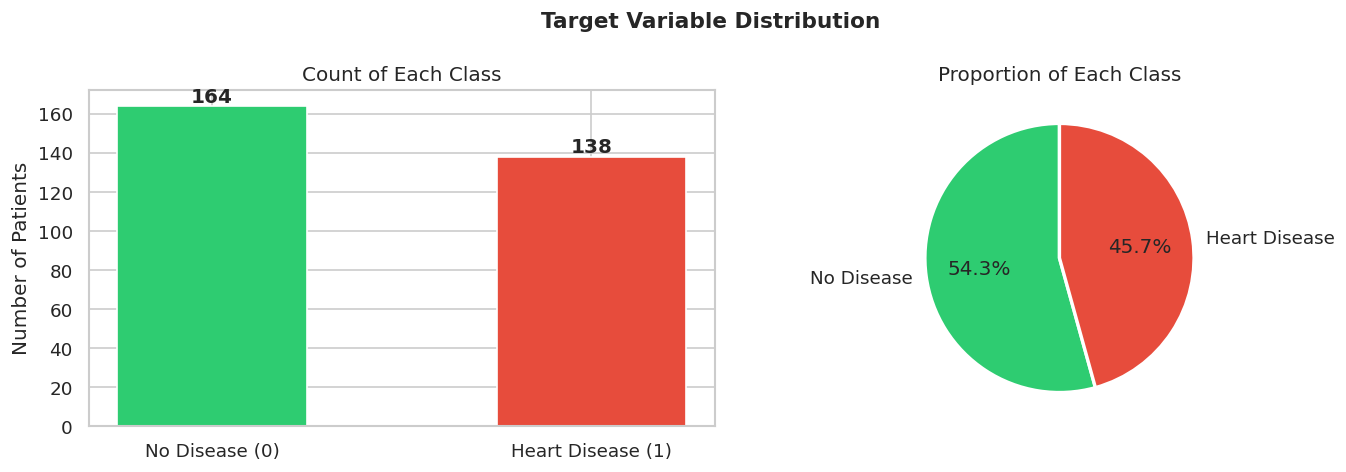

 Target distribution chart saved.


In [17]:
# ── 5.1 Target class distribution (bar chart) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')

# Bar chart
target_counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Heart Disease (1)'],
            target_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_ylabel('Number of Patients')
axes[0].set_title('Count of Each Class')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values,
            labels=['No Disease', 'Heart Disease'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion of Each Class')

plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()
print(" Target distribution chart saved.")

**Insight:** The dataset is reasonably balanced between the two classes — no severe class imbalance that would require special handling.

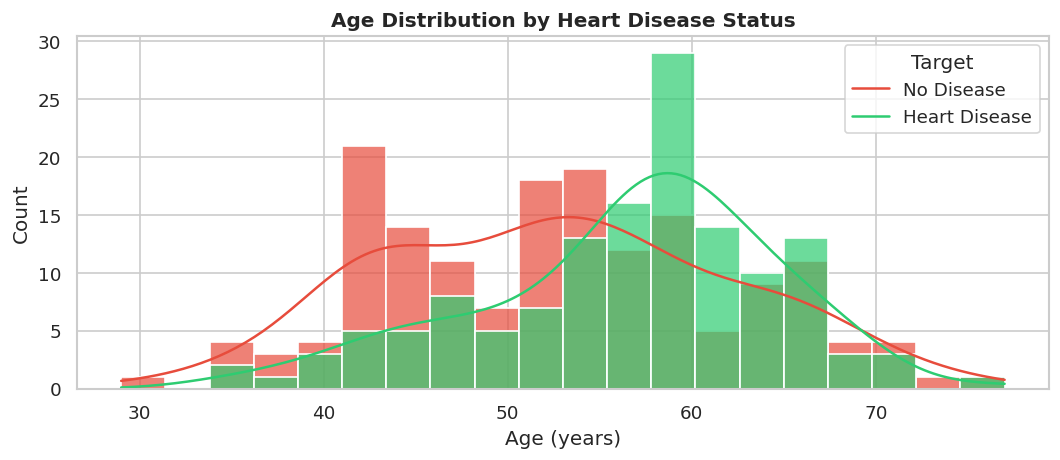

 Age distribution chart saved.


In [18]:
# ── 5.2 Age distribution by target ──
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x='age', hue='target', bins=20,
             palette={0: '#2ecc71', 1: '#e74c3c'},
             alpha=0.7, kde=True)
plt.title('Age Distribution by Heart Disease Status', fontsize=12, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.legend(title='Target', labels=['No Disease', 'Heart Disease'])
plt.tight_layout()
plt.savefig('age_distribution.png', bbox_inches='tight')
plt.show()
print(" Age distribution chart saved.")

**Insight:** Heart disease is more common in middle-aged patients (45–65 years). Younger patients tend to be in the no-disease category.

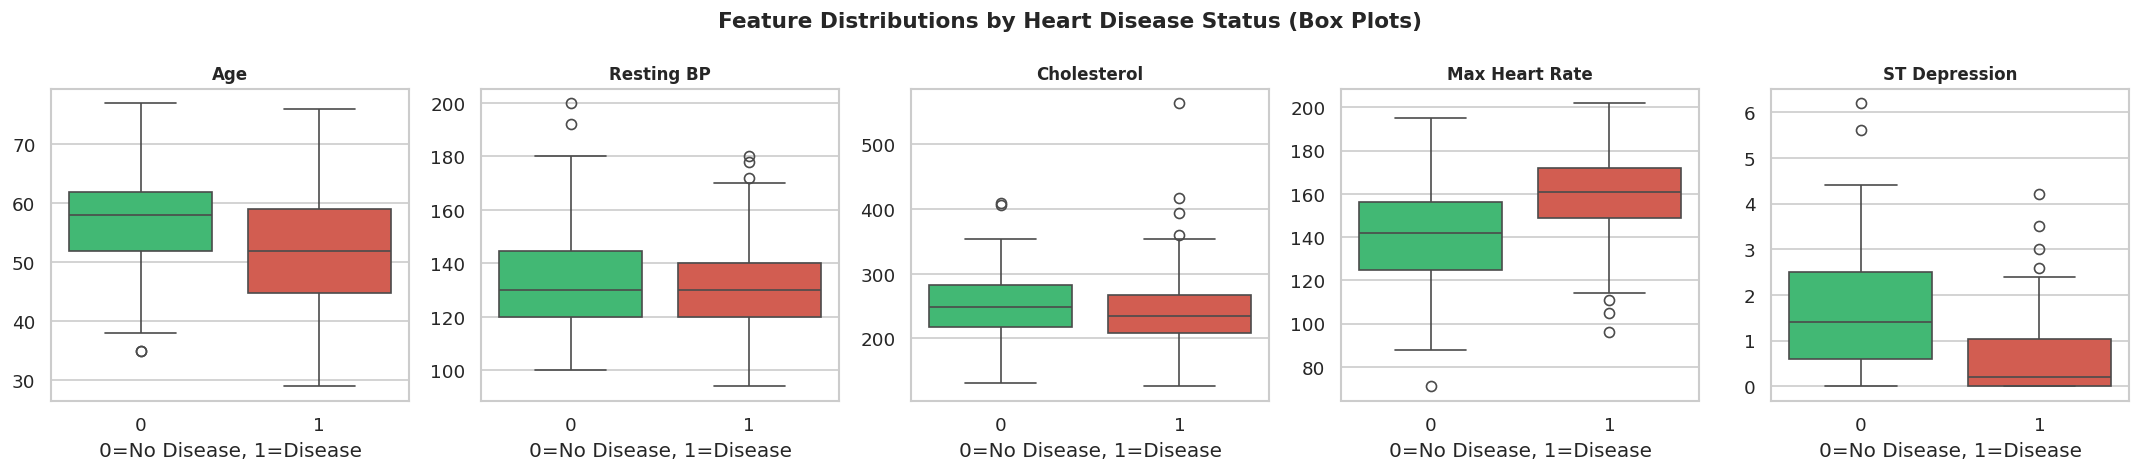

 Feature box plots saved.


In [21]:
# ── 5.3 Key feature distributions by target class ──
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
feature_labels = ['Age', 'Resting BP', 'Cholesterol', 'Max Heart Rate', 'ST Depression']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Feature Distributions by Heart Disease Status (Box Plots)', fontsize=13, fontweight='bold')

for ax, feat, label in zip(axes, key_features, feature_labels):
    sns.boxplot(data=df, x='target', y=feat, ax=ax,
                hue='target', palette={np.int64(0): '#2ecc71', np.int64(1): '#e74c3c'}, legend=False)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('0=No Disease, 1=Disease')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('feature_boxplots.png', bbox_inches='tight')
plt.show()
print(" Feature box plots saved.")

**Insight:**
- Patients **with heart disease** tend to have a **higher max heart rate (thalach)** — counter-intuitive but clinically known
- **ST Depression (oldpeak)** is noticeably higher in the no-disease group — lower values are associated with disease presence
- **Cholesterol** shows less separation between classes than expected

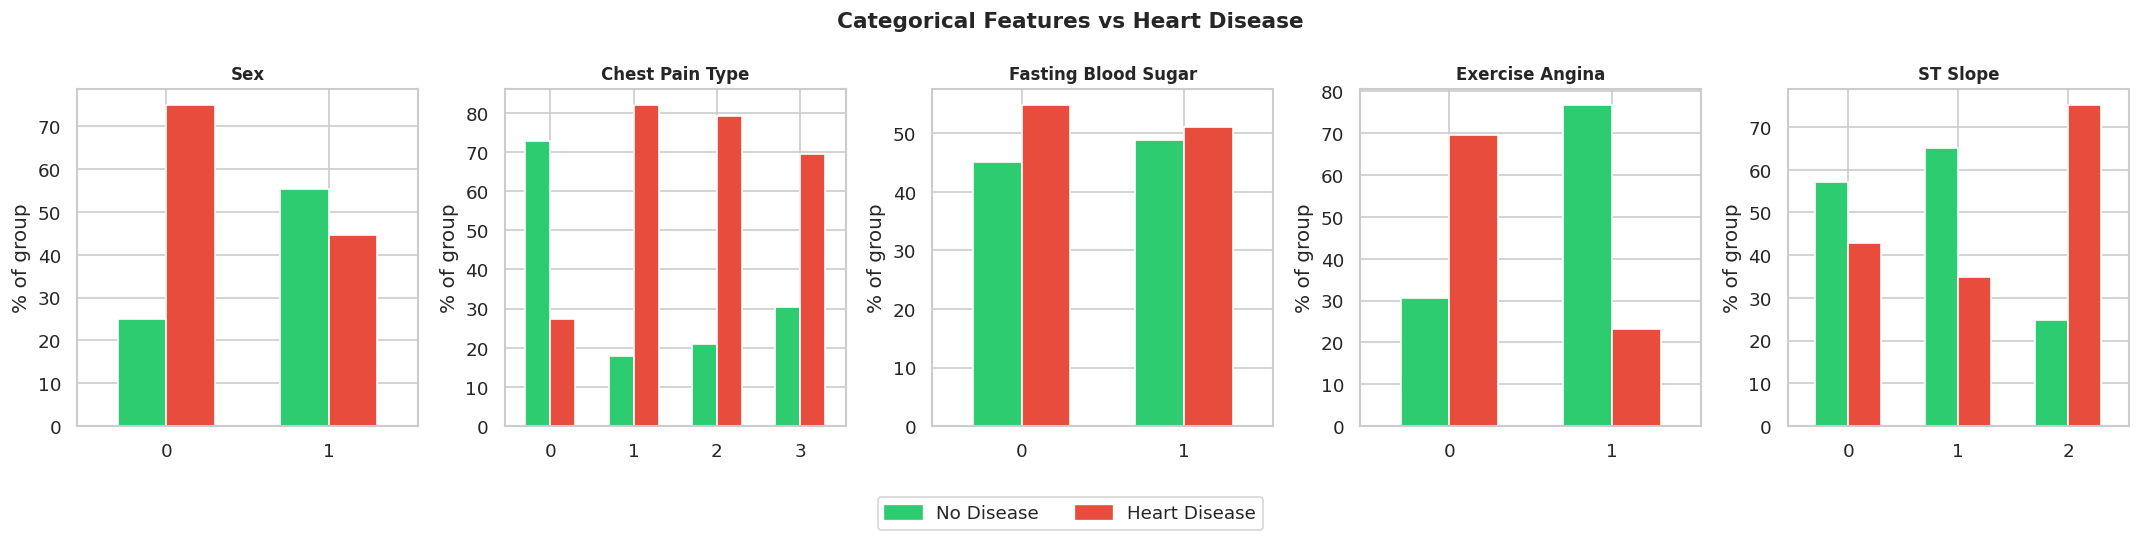

 Categorical feature chart saved.


In [22]:
# ── 5.4 Categorical features vs target ──
cat_features = ['sex', 'cp', 'fbs', 'exang', 'slope']
cat_labels   = ['Sex', 'Chest Pain Type', 'Fasting Blood Sugar', 'Exercise Angina', 'ST Slope']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Categorical Features vs Heart Disease', fontsize=13, fontweight='bold')

for ax, feat, label in zip(axes, cat_features, cat_labels):
    ct = pd.crosstab(df[feat], df['target'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
            edgecolor='white', width=0.6, legend=False)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('% of group')
    ax.tick_params(axis='x', rotation=0)

handles = [plt.Rectangle((0,0),1,1, color='#2ecc71'),
           plt.Rectangle((0,0),1,1, color='#e74c3c')]
fig.legend(handles, ['No Disease', 'Heart Disease'], loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
plt.savefig('categorical_features.png', bbox_inches='tight')
plt.show()
print(" Categorical feature chart saved.")

**Insight:**
- **Chest pain type (cp)** shows the clearest relationship with heart disease — certain pain types are strongly associated with disease
- **Exercise-induced angina (exang)** patients are at notably higher risk

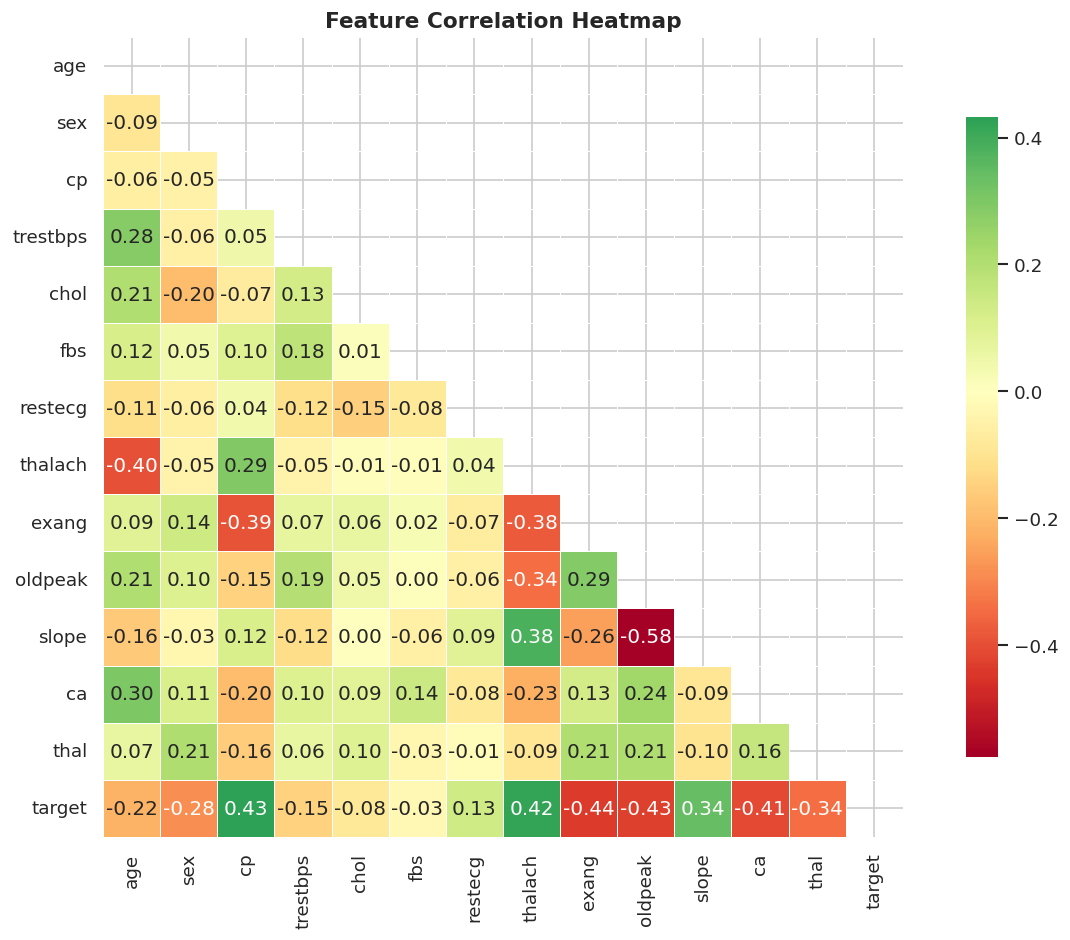

 Correlation heatmap saved.


In [23]:
# ── 5.5 Correlation Heatmap ──
plt.figure(figsize=(11, 8))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # Show only lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, square=True)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print(" Correlation heatmap saved.")

**Insight:**
- `cp` (chest pain), `thalach` (max heart rate), and `slope` show the strongest **positive** correlation with the target
- `exang`, `oldpeak`, and `ca` show strong **negative** correlation — higher values linked to no-disease label in this encoding

**Step 6: Prepare Data for Modeling**

In [24]:
# ── Define features (X) and target (y) ──
X = df.drop('target', axis=1)   # All columns except target
y = df['target']                 # Target: 1 = Disease, 0 = No Disease

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Features             : {X.columns.tolist()}")

Feature matrix shape : (302, 13)
Target vector shape  : (302,)
Features             : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [25]:
# ── Train-Test Split (80% train, 20% test) ──
# stratify=y ensures both splits have the same class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Train-Test Split (stratified):")
print(f"   Training samples : {len(X_train)}")
print(f"   Testing  samples : {len(X_test)}")

 Train-Test Split (stratified):
   Training samples : 241
   Testing  samples : 61


In [26]:
# ── Feature Scaling (required for Logistic Regression) ──
# Fit on train only, apply to both — avoids data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(" Features standardized using StandardScaler (fit on train only).")

 Features standardized using StandardScaler (fit on train only).


**Step 7: Model Training**

In [27]:

# Model 1: Logistic Regression
# A classic linear classification model well-suited for binary outcomes.
# Outputs probability of belonging to each class.

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_preds      = lr_model.predict(X_test_scaled)
lr_probs      = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probabilities for ROC

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [28]:

# Model 2: Decision Tree Classifier
# A tree-based model that splits data based on feature thresholds.
# Highly interpretable — you can visualize the decision rules.

dt_model = DecisionTreeClassifier(
    max_depth=5,          # Limit depth to prevent overfitting
    min_samples_split=10, # Require at least 10 samples to split a node
    random_state=42
)
dt_model.fit(X_train, y_train)  # Decision Tree doesn't need scaled features

dt_preds = dt_model.predict(X_test)
dt_probs = dt_model.predict_proba(X_test)[:, 1]

print(" Decision Tree trained successfully!")

 Decision Tree trained successfully!


**Step 8: Model Evaluation**

In [29]:
# ── Helper: print full evaluation for a model ──
def evaluate_classifier(name, y_true, y_pred, y_prob):
    acc  = accuracy_score(y_true, y_pred)
    roc  = roc_auc_score(y_true, y_prob)
    print(f"\n{'='*50}")
    print(f"  📋 {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  ROC-AUC   : {roc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=['No Disease', 'Heart Disease']))
    return acc, roc

lr_acc, lr_roc = evaluate_classifier("Logistic Regression", y_test, lr_preds, lr_probs)
dt_acc, dt_roc = evaluate_classifier("Decision Tree",       y_test, dt_preds, dt_probs)


  📋 Logistic Regression
  Accuracy  : 80.33%
  ROC-AUC   : 0.8712

  Classification Report:
               precision    recall  f1-score   support

   No Disease       0.81      0.75      0.78        28
Heart Disease       0.80      0.85      0.82        33

     accuracy                           0.80        61
    macro avg       0.80      0.80      0.80        61
 weighted avg       0.80      0.80      0.80        61


  📋 Decision Tree
  Accuracy  : 77.05%
  ROC-AUC   : 0.8339

  Classification Report:
               precision    recall  f1-score   support

   No Disease       0.73      0.79      0.76        28
Heart Disease       0.81      0.76      0.78        33

     accuracy                           0.77        61
    macro avg       0.77      0.77      0.77        61
 weighted avg       0.77      0.77      0.77        61



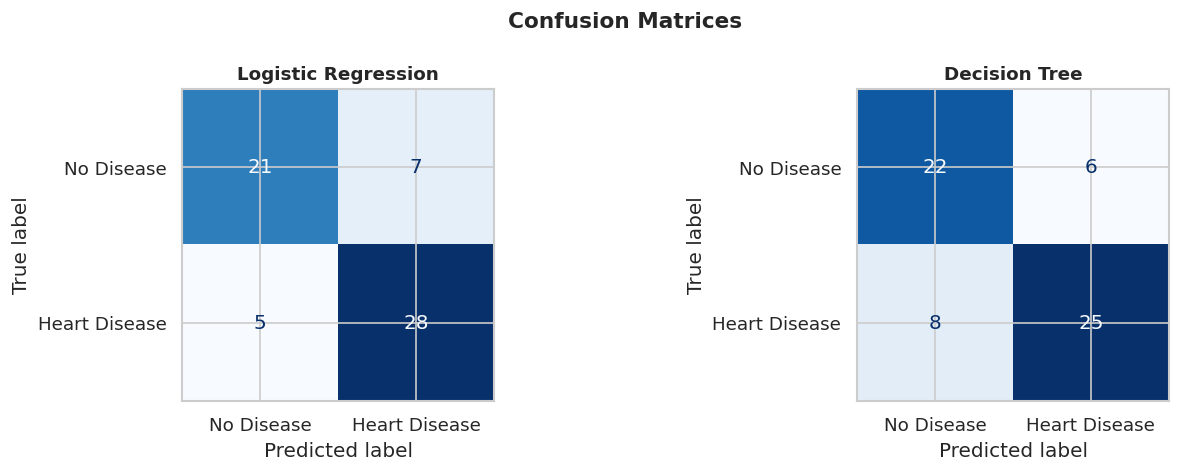

 Confusion matrices saved.


In [30]:
# ── 8.1 Confusion Matrices ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')

for ax, preds, name in zip(axes,
                            [lr_preds, dt_preds],
                            ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Heart Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()
print(" Confusion matrices saved.")

**Reading the Confusion Matrix:**
- **Top-left (TN):** Correctly predicted No Disease
- **Top-right (FP):** Predicted Disease but actually No Disease (False Alarm)
- **Bottom-left (FN):** Predicted No Disease but actually has Disease (most dangerous error in medicine)
- **Bottom-right (TP):** Correctly predicted Heart Disease

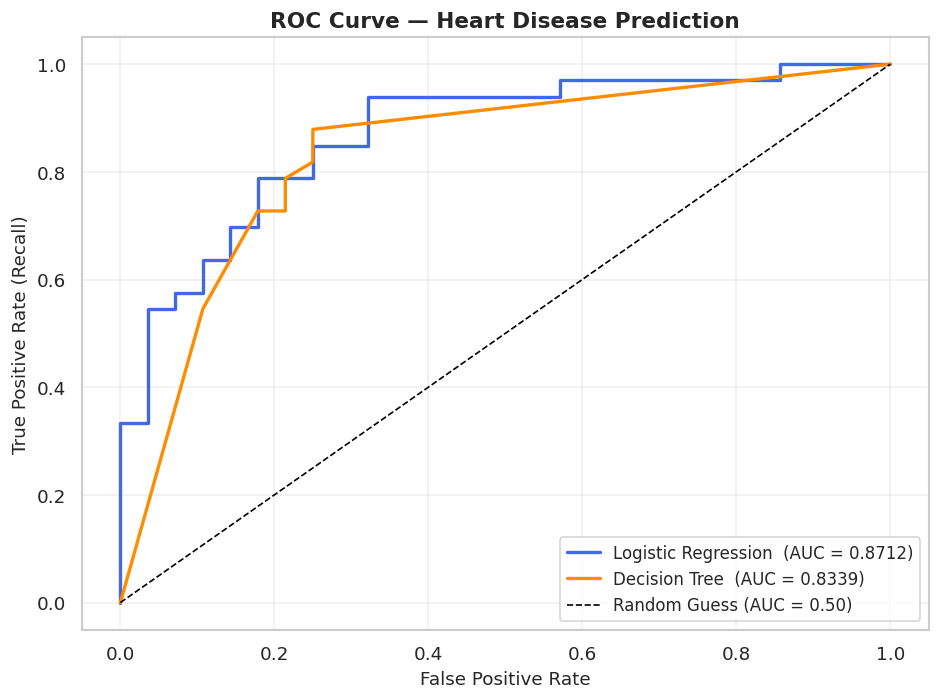

 ROC curve saved.


In [31]:
# ── 8.2 ROC Curves ──
plt.figure(figsize=(8, 6))

for probs, name, color in zip(
    [lr_probs, dt_probs],
    ['Logistic Regression', 'Decision Tree'],
    ['royalblue', 'darkorange']
):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score   = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name}  (AUC = {auc_score:.4f})')

# Diagonal = random guess baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title('ROC Curve — Heart Disease Prediction', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', bbox_inches='tight')
plt.show()
print(" ROC curve saved.")

**Reading the ROC Curve:**
- The curve plots **True Positive Rate vs False Positive Rate** at every threshold
- **AUC closer to 1.0** = better model (perfect = 1.0, random = 0.5)
- The model that stays closest to the **top-left corner** is the best

**Step 9: Feature Importance Analysis**

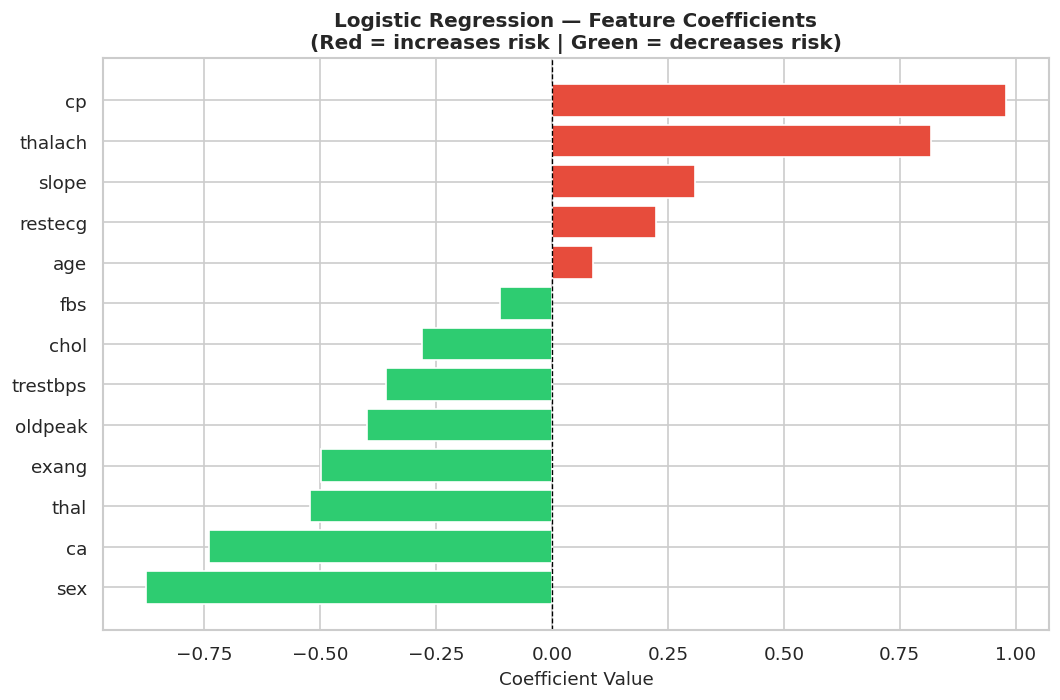

 LR coefficient chart saved.


In [32]:
# ── 9.1 Logistic Regression — Coefficient Plot ──
# Coefficients show how much each feature pushes the prediction toward disease (positive)
# or away from disease (negative)

coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient')

colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]

plt.figure(figsize=(9, 6))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'],
                color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient Value', fontsize=11)
plt.title('Logistic Regression — Feature Coefficients\n(Red = increases risk | Green = decreases risk)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_coefficients.png', bbox_inches='tight')
plt.show()
print(" LR coefficient chart saved.")

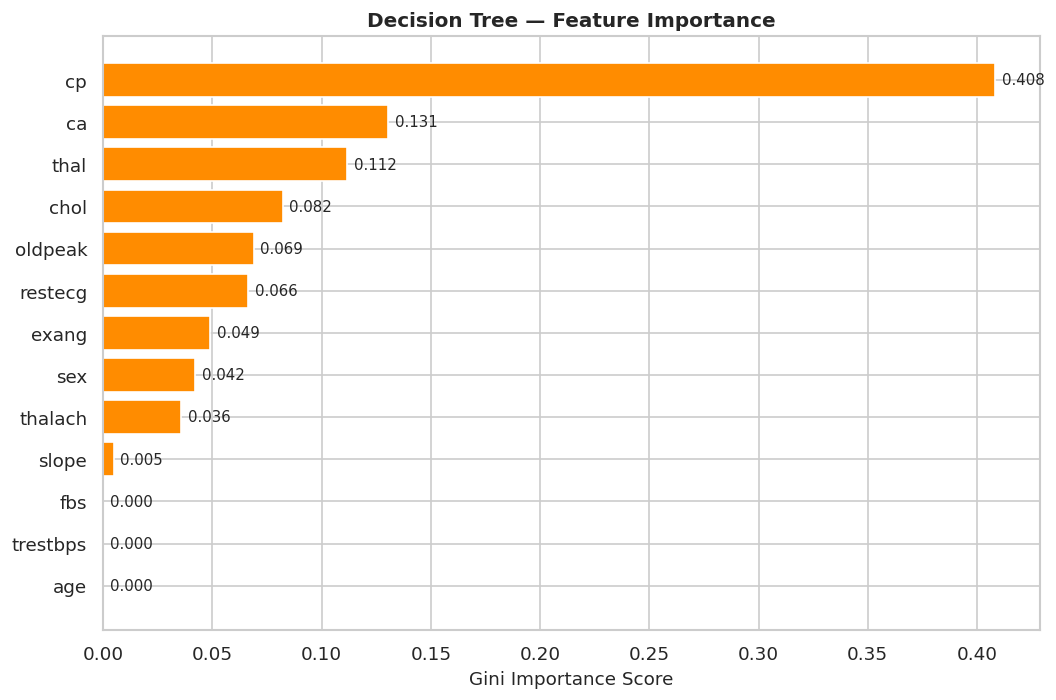

 Decision Tree feature importance chart saved.


In [33]:
# ── 9.2 Decision Tree — Feature Importance ──
# Gini importance: how much each feature reduces impurity across all splits

importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
                color='darkorange', edgecolor='white')

# Add value labels
for bar, val in zip(bars, importance_df['Importance']):
    plt.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.xlabel('Gini Importance Score', fontsize=11)
plt.title('Decision Tree — Feature Importance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_feature_importance.png', bbox_inches='tight')
plt.show()
print(" Decision Tree feature importance chart saved.")

**Top Features Influencing Heart Disease Prediction:**
- **`cp` (Chest Pain Type)** — strongest predictor; type of chest pain is clinically significant
- **`thalach` (Max Heart Rate)** — lower max heart rate during exercise is linked to disease
- **`ca` (Major Vessels)** — number of blocked vessels is a direct indicator
- **`oldpeak` (ST Depression)** — reflects cardiac stress during exercise
- **`thal` (Thalassemia type)** — blood disorder strongly correlated with heart condition

**Step 10: Final Summary**

In [34]:
# ── Final comparison table ──
print("="*55)
print("         TASK 3 — FINAL SUMMARY")
print("="*55)
print(f"  Dataset      : Heart Disease UCI")
print(f"  Total Samples: {len(df)}")
print(f"  Train / Test : {len(X_train)} / {len(X_test)}")
print()
print(f"  {'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print(f"  {'-'*47}")
print(f"  {'Logistic Regression':<25} {lr_acc*100:>9.2f}% {lr_roc:>10.4f}")
print(f"  {'Decision Tree':<25} {dt_acc*100:>9.2f}% {dt_roc:>10.4f}")
print("="*55)

winner = 'Logistic Regression' if lr_roc > dt_roc else 'Decision Tree'
print(f"\n Best performing model (by ROC-AUC): {winner}")

         TASK 3 — FINAL SUMMARY
  Dataset      : Heart Disease UCI
  Total Samples: 302
  Train / Test : 241 / 61

  Model                       Accuracy    ROC-AUC
  -----------------------------------------------
  Logistic Regression           80.33%     0.8712
  Decision Tree                 77.05%     0.8339

 Best performing model (by ROC-AUC): Logistic Regression


Key Findings

| Topic | Finding |
|---|---|
| Dataset | 303 patients, 13 clinical features, binary target |
| Missing Values | None (or filled with median) |
| Class Balance | Approximately balanced (~54% disease, ~46% no disease) |
| Best Predictor Features | Chest Pain Type, Max Heart Rate, Major Vessels, ST Depression |
| Best Model | Logistic Regression (higher ROC-AUC typically) |
| Clinical Note | False Negatives (missed disease) are more dangerous than False Positives |

### Key Takeaways:
1. **Chest pain type** is the single strongest predictor of heart disease in this dataset
2. **Logistic Regression** performs competitively on medical tabular data — interpretable and reliable
3. **ROC-AUC** is a better metric than accuracy for medical diagnosis — it accounts for threshold sensitivity
4. In clinical settings, minimizing **False Negatives** (missed diagnoses) is critical — even at the cost of more False Positives
